In [3]:
import pandas as pd

df = pd.read_csv("./Dataset/retail_sales_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [5]:
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

In [6]:
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (snapshot_date - x.max()).days,
    'Transaction ID': 'count',
    'Total Amount': 'sum'
}).reset_index()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [7]:
rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

print(rfm.head())

  CustomerID  Recency  Frequency  Monetary
0    CUST001       20         14      4555
1    CUST002        7         15      7250
2    CUST003        9         16      5990
3    CUST004       45         15      9100
4    CUST005        6          8      3980


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(scaled_data)

In [10]:
summary = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

print(summary)

            Recency  Frequency      Monetary
Cluster                                     
0         49.954774   1.844221    833.417085
1        173.880829   1.000000    493.108808
2         12.333333  73.000000  30758.333333
3        297.036199   1.000000    464.728507


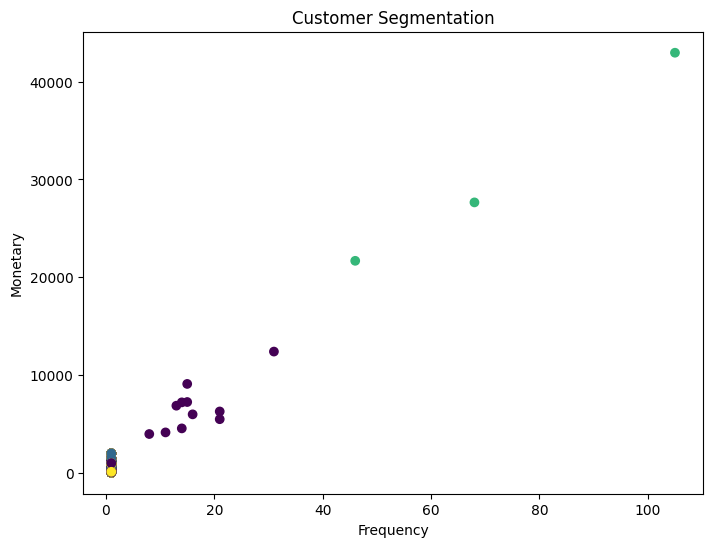

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segmentation')

plt.savefig('Cluster_Plot.png')
plt.show()

In [24]:
print(rfm['Frequency'].value_counts())

Frequency
1      602
14       2
21       2
15       2
8        1
16       1
46       1
13       1
105      1
31       1
68       1
11       1
Name: count, dtype: int64


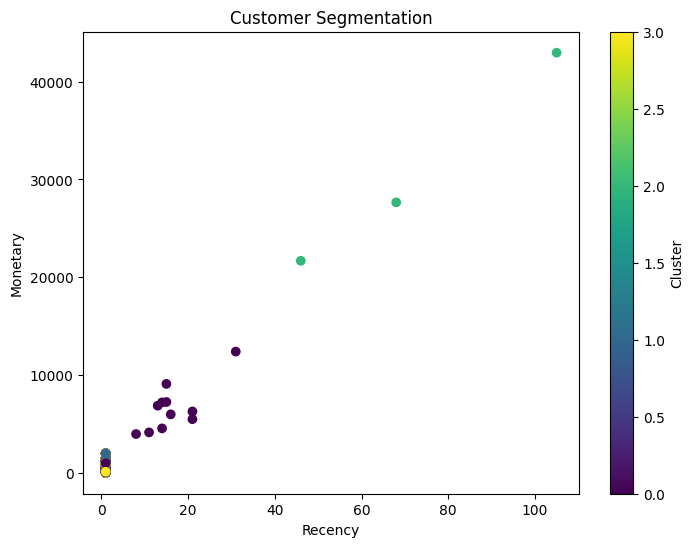

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation")
plt.colorbar(label="Cluster")

plt.savefig("Cluster_Plot.png")
plt.show()